Loaded: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/history.npy
History type: <class 'dict'>
Top-level keys: ['lr', 'train_acc', 'train_loss', 'val_acc', 'val_loss', 'val_per_snr']
Sequence lengths: {'train_loss': 30, 'train_acc': 30, 'val_loss': 30, 'val_acc': 30, 'val_per_snr': 30, 'lr': 30}

Columns: ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_per_snr', 'lr']


,train_loss,train_acc,val_loss,val_acc,val_per_snr,lr
0,2.632988,33.324379,1.686064,54.839424,"{-5: {'loss': 1.9338612291289459, 'acc': 37.09...",0.001
1,1.080561,65.721961,0.690301,80.243632,"{-5: {'loss': 1.3694305002623355, 'acc': 56.14...",0.001
2,0.770500,75.395567,0.444913,85.957918,"{-5: {'loss': 1.1572469061512833, 'acc': 63.23...",0.001
3,0.651508,79.057085,0.362939,88.947951,"{-5: {'loss': 1.0783933748271428, 'acc': 65.73...",0.001
4,0.596599,80.870383,0.427452,87.884828,"{-5: {'loss': 0.9545912023968912, 'acc': 69.16...",0.001



LR-related columns: ['lr']

lr
  epochs_logged: 30
  first -> last: 0.001 -> 6.25e-05
  min / max: 6.25e-05 / 0.001
  unique values (5): [6.25e-05 1.25e-04 2.50e-04 5.00e-04 1.00e-03]
  LR changed through epochs: True


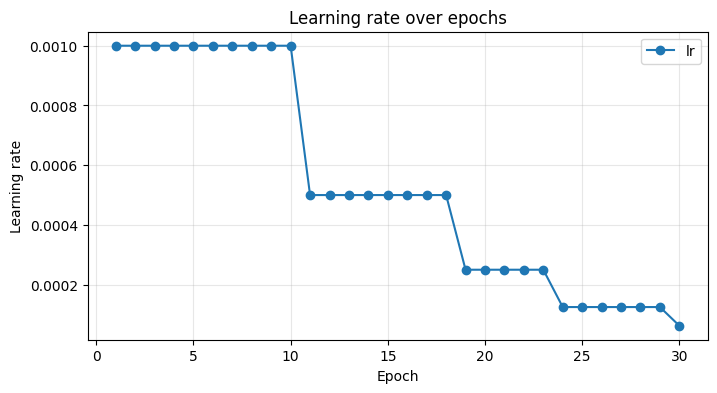

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

history_path = Path("/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/history.npy")
raw = np.load(history_path, allow_pickle=True)
history = raw.item() if isinstance(raw, np.ndarray) and raw.shape == () else raw


def to_dataframe(obj):
    if isinstance(obj, dict):
        if all(isinstance(v, (list, tuple, np.ndarray, pd.Series)) for v in obj.values()):
            lengths = {k: len(v) for k, v in obj.items()}
            print("Sequence lengths:", lengths)
            if len(set(lengths.values())) == 1:
                return pd.DataFrame({k: list(v) for k, v in obj.items()})
        return pd.DataFrame([obj])

    if isinstance(obj, (list, tuple)):
        if len(obj) > 0 and isinstance(obj[0], dict):
            return pd.DataFrame(list(obj))
        return pd.DataFrame({"value": list(obj)})

    if isinstance(obj, np.ndarray):
        if obj.dtype.names:
            return pd.DataFrame(obj)
        if obj.ndim == 1 and len(obj) > 0 and isinstance(obj[0], dict):
            return pd.DataFrame(list(obj))
        return pd.DataFrame(obj)

    raise TypeError(f"Unsupported history type: {type(obj)}")


print(f"Loaded: {history_path}")
print("History type:", type(history))

if isinstance(history, dict):
    print("Top-level keys:", sorted(history.keys()))

df = to_dataframe(history)
print("\nColumns:", list(df.columns))
display(df.head())

lr_columns = [
    col for col in df.columns
    if "lr" in str(col).lower() or "learning_rate" in str(col).lower()
]

print("\nLR-related columns:", lr_columns)

if not lr_columns and isinstance(history, dict):
    nested_lr_keys = [
        key for key in history.keys()
        if "lr" in str(key).lower() or "learning_rate" in str(key).lower()
    ]
    print("Nested/top-level LR keys:", nested_lr_keys)

if lr_columns:
    lr_summary = {}
    plt.figure(figsize=(8, 4))

    for col in lr_columns:
        series = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy()
        if len(series) == 0:
            print(f"Skipping {col}: no numeric values")
            continue

        changed = not np.allclose(series, series[0])
        unique_values = np.unique(np.round(series, 12))
        lr_summary[col] = {
            "epochs_logged": len(series),
            "first": float(series[0]),
            "last": float(series[-1]),
            "min": float(series.min()),
            "max": float(series.max()),
            "num_unique": int(len(unique_values)),
            "changed": bool(changed),
        }

        print(f"\n{col}")
        print(f"  epochs_logged: {len(series)}")
        print(f"  first -> last: {series[0]} -> {series[-1]}")
        print(f"  min / max: {series.min()} / {series.max()}")
        print(f"  unique values ({len(unique_values)}): {unique_values[:10]}")
        print(f"  LR changed through epochs: {changed}")

        plt.plot(np.arange(1, len(series) + 1), series, marker="o", label=str(col))

    if lr_summary:
        plt.xlabel("Epoch")
        plt.ylabel("Learning rate")
        plt.title("Learning rate over epochs")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        pd.DataFrame(lr_summary).T
else:
    print("No LR column found in the tabular history. Inspect the printed keys/columns above.")

In [4]:
import json
import torch

from thesis_project.models.keyword_spotting import KWSBase, KeyWordSpottingBaseConfig

run_dir = Path("/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50")
config_path = run_dir / "base_config.json"
checkpoint_path = run_dir / "best_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

with open(config_path, "r") as f:
    cfg_dict = json.load(f)

base_cfg = KeyWordSpottingBaseConfig(**cfg_dict)
base_model = KWSBase(base_cfg).to(device)
state_dict = torch.load(checkpoint_path, map_location=device)
base_model.load_state_dict(state_dict)
base_model.eval()

total_params = sum(p.numel() for p in base_model.parameters())
trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)

print(f"Loaded baseline from: {checkpoint_path}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

Using device: mps
Loaded baseline from: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/best_model.pth
Total parameters: 338,718
Trainable parameters: 338,718 (100.00%)


## Baseline parameter count (LaTeX)

For the full-rank baseline model:

$$
P \approx P_{\text{frontend}} + P_{\text{backbone}} + P_{\text{classifier}}
$$

with

$$
P_{\text{frontend}} = C_{\text{ext}}F + C_{\text{ext}}
$$

$$
P_{\text{block}} = 2C_{\text{ext}}C_{\text{int}} + kC_{\text{int}} + 5C_{\text{int}} + 2
$$

$$
P_{\text{backbone}} = (N_{\text{stacks}}N_{\text{blocks}})\,P_{\text{block}}
$$

$$
P_{\text{classifier}} = C_{\text{ext}}N_{\text{cls}} + N_{\text{cls}}
$$

So:

$$
P \approx (C_{\text{ext}}F + C_{\text{ext}}) + (N_{\text{stacks}}N_{\text{blocks}})(2C_{\text{ext}}C_{\text{int}} + kC_{\text{int}} + 5C_{\text{int}} + 2) + (C_{\text{ext}}N_{\text{cls}} + N_{\text{cls}})
$$

Using this run's config:

$$
F = \frac{n_{\text{fft}}}{2}+1 = 257,\quad C_{\text{ext}}=128,\quad C_{\text{int}}=128,\quad k=3,
$$
$$
N_{\text{stacks}}=3,\quad N_{\text{blocks}}=3,\quad N_{\text{cls}}=12
$$

$$
P = 33{,}024 + 9\cdot 33{,}794 + 1{,}548 = 338{,}718
$$